# Bank Marketing Subscription-Propensity Pipeline — Model Development

Interactive companion to `build_pipeline.py`. Explores the data, builds the
`ColumnTransformer(MeanTargetEncoder + StandardScaler) -> LogisticRegression`
pipeline using the shared functions in `build_pipeline.py` / `pipeline_def.py`,
fits it, evaluates it, and inspects the learned state that makes this a *real*
fitted pipeline (not something that could be rebuilt from scratch at boot).


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from build_pipeline import (
    load_data, build_pipeline, evaluate,
    CAT_COLUMNS, NUM_COLUMNS, FEATURE_COLUMNS, TARGET_COLUMN,
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)


## 1. Load & inspect raw data

In [2]:
df = load_data("../data/bankmarketing.csv")
print(df.shape)
df.head()


(41188, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_binary
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [3]:
df[TARGET_COLUMN].value_counts(normalize=True)


y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [4]:
df[NUM_COLUMNS].describe()


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


`duration` is deliberately **excluded** from `FEATURE_COLUMNS`: it's only known
*after* a call ends (duration≈0 almost always implies `y=no`), so it leaks the
outcome and isn't a legitimate input for a pre-call propensity estimate.


In [5]:
FEATURE_COLUMNS


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

## 2. Quick EDA — subscription rate by category

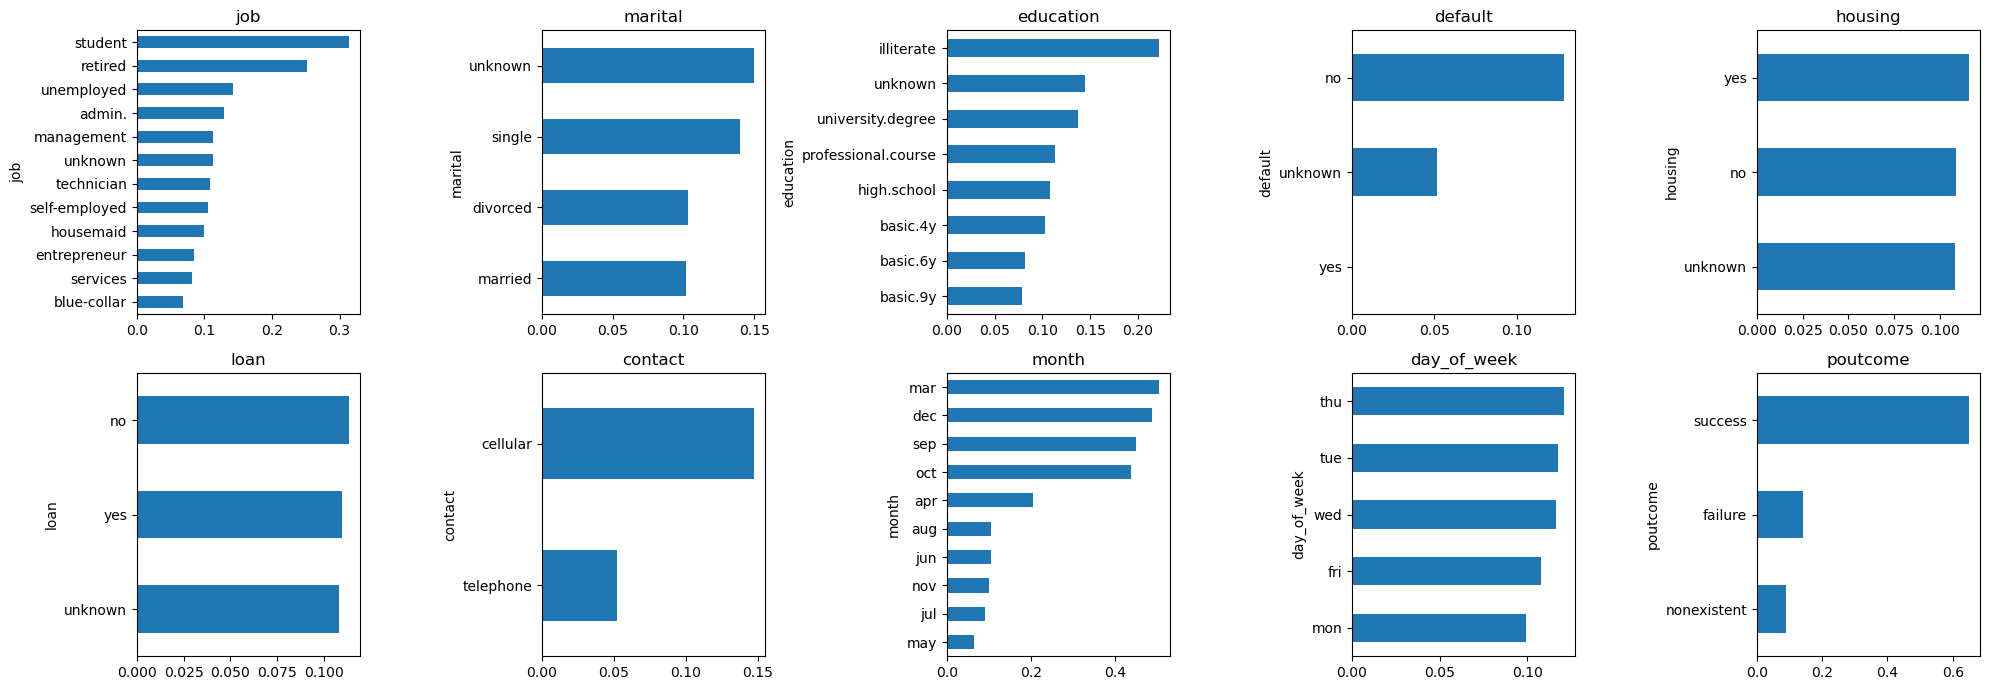

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), CAT_COLUMNS):
    rates = df.groupby(col)[TARGET_COLUMN].apply(lambda s: (s == "yes").mean()).sort_values()
    rates.plot(kind="barh", ax=ax, title=col)
plt.tight_layout()
plt.show()


## 3. Train / test split

In [7]:
X = df[FEATURE_COLUMNS]
y = df["y_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((32950, 19),
 (8238, 19),
 np.float64(0.11265553869499241),
 np.float64(0.11264870114105366))

## 4. Build & fit the pipeline

`build_pipeline()` returns an **unfit** `sklearn.Pipeline`. Calling `.fit()` is
what produces the learned state (the `MeanTargetEncoder.mapping_` dict and the
`LogisticRegression` coefficients) that gets serialized into the `.joblib`
bundle. An unfit pipeline (or one rebuilt fresh at API boot without re-fitting)
has none of that state.


In [8]:
pipeline = build_pipeline()
pipeline


Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('cat',
                                                  MeanTargetEncoder(columns=['job',
                                                                             'marital',
                                                                             'education',
                                                                             'default',
                                                                             'housing',
                                                                             'loan',
                                                                             'contact',
                                                                             'month',
                                                                             'day_of_week',
                                                                             'poutcome']),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [9]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('cat',
                                                  MeanTargetEncoder(columns=['job',
                                                                             'marital',
                                                                             'education',
                                                                             'default',
                                                                             'housing',
                                                                             'loan',
                                                                             'contact',
                                                                             'month',
                                                                             'day_of_week',
                                                                             'poutcome']),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed'])])),
                ('clf', LogisticRegression(max_iter=1000))])

## 5. Evaluate on held-out test data

In [10]:
metrics = evaluate(pipeline, X_test, y_test)
print(f"Test ROC AUC: {metrics['roc_auc']:.4f}")
print(pd.DataFrame(metrics["report"]).T)


Test ROC AUC: 0.7929
              precision    recall  f1-score     support
0              0.907468  0.987415  0.945755  7310.00000
1              0.676056  0.206897  0.316832   928.00000
accuracy       0.899490  0.899490  0.899490     0.89949
macro avg      0.791762  0.597156  0.631293  8238.00000
weighted avg   0.881400  0.899490  0.874907  8238.00000


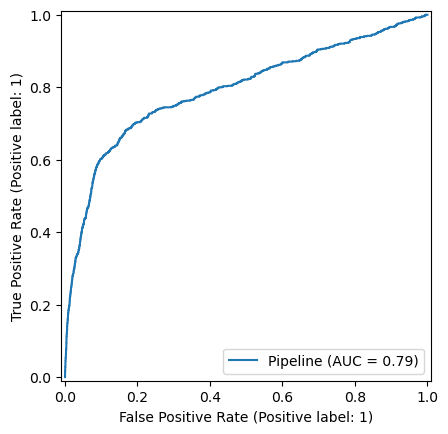

In [11]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
plt.show()


## 6. Inspect the custom transformer's learned state

This is the "wrong if rebuilt from scratch at boot" part: `mapping_` is a
per-category smoothed target rate learned from the *training* split. A freshly
constructed `MeanTargetEncoder` has no `mapping_` at all.


In [12]:
encoder = pipeline.named_steps["features"].named_transformers_["cat"]
print("global_mean_:", encoder.global_mean_)
encoder.mapping_["poutcome"]


global_mean_: 0.11265553869499241


{'failure': 0.14397399109826983,
 'nonexistent': 0.08802246377917927,
 'success': 0.6440596909299999}

In [13]:
encoder.mapping_["month"]


{'apr': 0.20435635102002384,
 'aug': 0.10732685667344694,
 'dec': 0.47795134239836545,
 'jul': 0.09234826873150007,
 'jun': 0.10385871632298566,
 'mar': 0.4890729941411433,
 'may': 0.06352659063487433,
 'nov': 0.10168698271884918,
 'oct': 0.4273476639647402,
 'sep': 0.43908555988808}

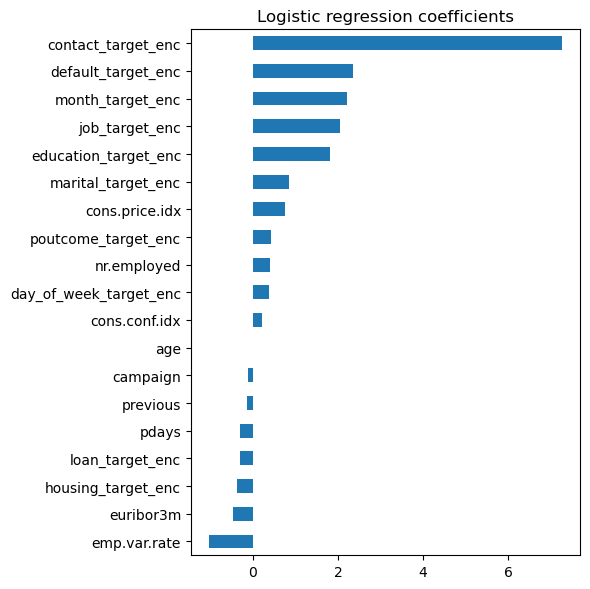

In [14]:
clf = pipeline.named_steps["clf"]
feature_names = list(encoder.get_feature_names_out()) + NUM_COLUMNS
coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values()
coefs.plot(kind="barh", figsize=(6, 6), title="Logistic regression coefficients")
plt.tight_layout()
plt.show()


## 7. Sanity check a single prediction (mirrors what the API will do)

In [15]:
sample = X_test.iloc[[0]]
proba = pipeline.predict_proba(sample)[0, 1]
print(sample.to_dict(orient="records")[0])
print(f"Predicted subscribe probability: {proba:.4f} (actual y={y_test.iloc[0]})")


{'job': 'management', 'marital': 'divorced', 'education': 'university.degree', 'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'cellular', 'month': 'jul', 'day_of_week': 'tue', 'poutcome': 'nonexistent', 'age': 32, 'campaign': 5, 'pdays': 999, 'previous': 0, 'emp.var.rate': 1.4, 'cons.price.idx': 93.918, 'cons.conf.idx': -42.7, 'euribor3m': 4.961, 'nr.employed': 5228.1}
Predicted subscribe probability: 0.0546 (actual y=0)


## 8. Dump the bundle

Equivalent to running `python build_pipeline.py` from the project root — this
cell exists so you can iterate on the pipeline here and re-dump without leaving
the notebook.


In [16]:
import joblib, sklearn, datetime as dt

bundle = {
    "pipeline": pipeline,
    "cat_columns": CAT_COLUMNS,
    "num_columns": NUM_COLUMNS,
    "target_rate": float(y_train.mean()),
    "metadata": {
        "steps": [name for name, _ in pipeline.steps],
        "built_at": dt.datetime.now(dt.timezone.utc).isoformat(),
        "sklearn_version": sklearn.__version__,
        "n_train_rows": int(len(X_train)),
        "n_test_rows": int(len(X_test)),
        "test_roc_auc": float(metrics["roc_auc"]),
        "model_type": "LogisticRegression",
        "custom_transformer": "MeanTargetEncoder",
        "target_column": TARGET_COLUMN,
        "description": (
            "Bank telemarketing subscription-propensity pipeline: smoothed "
            "mean-target encoding (custom transformer) on categorical client "
            "fields + standardized macroeconomic/contact features, fed into "
            "a logistic regression that outputs a subscription probability."
        ),
    },
}

# Uncomment to overwrite the shipped artifact from the notebook:
# joblib.dump(bundle, "../pipeline.joblib")
bundle["metadata"]


{'steps': ['features', 'clf'],
 'built_at': '2026-09-14T02:44:56.887339+00:00',
 'sklearn_version': '1.6.1',
 'n_train_rows': 32950,
 'n_test_rows': 8238,
 'test_roc_auc': 0.7929279535591303,
 'model_type': 'LogisticRegression',
 'custom_transformer': 'MeanTargetEncoder',
 'target_column': 'y',
 'description': 'Bank telemarketing subscription-propensity pipeline: smoothed mean-target encoding (custom transformer) on categorical client fields + standardized macroeconomic/contact features, fed into a logistic regression that outputs a subscription probability.'}